# Modèle TF-IDF — Classification politique municipale

**Protocole :**
- **Train (80 %) :** 200 documents synthétiques générés par classe (`data/corpus_train.json`)
- **Test (20 %) :** 51 documents réels du corpus (`data/corpus.json`)

Classes : `EG` Extrême gauche | `G` Gauche | `C` Centre | `D` Droite | `ED` Extrême droite

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

os.makedirs('figures', exist_ok=True)
plt.rcParams['figure.dpi'] = 130

ORDER        = ['EG', 'G', 'C', 'D', 'ED']
LABEL_NAMES  = {'ED': 'Extrême droite', 'D': 'Droite', 'C': 'Centre',
                'G': 'Gauche', 'EG': 'Extrême gauche'}
COLORS       = {'ED': '#1a1a2e', 'D': '#1e6fd9', 'C': '#f5a623',
                'G': '#e8453c', 'EG': '#8B0000'}
THEMES       = ['securite', 'ecologie', 'economie', 'mobilite', 'education', 'sociale']

STOPWORDS_FR = set([
    'le','la','les','de','du','des','un','une','et','en','à','au','aux','par','pour',
    'sur','dans','qui','que','qu','il','ils','elle','elles','nous','vous','je','on',
    'ce','se','sa','son','ses','leur','leurs','mais','ou','donc','or','ni','car',
    'plus','est','sont','ont','être','avoir','avec','cette','ces','cet','tout',
    'tous','toute','toutes','notre','nos','vos','votre','y','ne','pas','si','très',
    'comme','même','aussi','bien','lors','dont','où','c','n','l','d','j','s','m',
    'a','an','fait','faire','mes','mon','ma','cette','cela','plus','après','avant',
    'suis','est','sommes','êtes','serait','sera','été','avons','avez','ont',
    'liste','municipale','municipales','mars','vote','candidat','candidats',
    'ville','villes','maire','maires','cid',
    'marine','pen','bardella','jordan','melenchon','macron','ciotti','zemmour',
])

## 1. Chargement des données

In [2]:
def load_corpus(path):
    with open(path, encoding='utf-8') as f:
        docs = json.load(f)
    texts, labels = [], []
    for d in docs:
        if d.get('y') and d['y'] != '?':
            text = ' '.join(d.get('themes', {}).values())
            texts.append(text)
            labels.append(d['y'])
    return texts, labels

X_train_raw, y_train = load_corpus('data/corpus_train.json')
X_test_raw,  y_test  = load_corpus('data/corpus.json')

print(f'Train : {len(X_train_raw)} docs | {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test  : {len(X_test_raw)}  docs | {pd.Series(y_test).value_counts().to_dict()}')

total = len(X_train_raw) + len(X_test_raw)
print(f'\nRépartition : train {len(X_train_raw)/total:.0%}  |  test {len(X_test_raw)/total:.0%}')

Train : 200 docs | {'EG': 40, 'ED': 40, 'G': 40, 'C': 40, 'D': 40}
Test  : 51  docs | {'C': 12, 'EG': 11, 'ED': 10, 'D': 10, 'G': 8}

Répartition : train 80%  |  test 20%


## 2. Vectorisation TF-IDF

Le vectoriseur est **fitté uniquement sur le train** pour éviter toute fuite d'information.

In [3]:
vectorizer = TfidfVectorizer(
    max_features=2000,
    min_df=2,
    ngram_range=(1, 2),
    stop_words=list(STOPWORDS_FR),
    lowercase=True,
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(X_train_raw)   # fit + transform sur train
X_test  = vectorizer.transform(X_test_raw)         # transform seulement sur test

print(f'Matrice train : {X_train.shape}')
print(f'Matrice test  : {X_test.shape}')

Matrice train : (200, 2000)
Matrice test  : (51, 2000)


## 3. Entraînement — Régression logistique

In [4]:
clf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    multi_class='multinomial',
)

clf.fit(X_train, y_train)
print(f'Modèle entraîné. Classes : {clf.classes_}')

Modèle entraîné. Classes : ['C' 'D' 'ED' 'EG' 'G']


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 4. Évaluation sur le corpus test (réel)

In [5]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy sur le corpus réel : {acc:.2%}\n')

print(classification_report(
    y_test, y_pred,
    labels=ORDER,
    target_names=[LABEL_NAMES[b] for b in ORDER]
))

Accuracy sur le corpus réel : 39.22%

                precision    recall  f1-score   support

Extrême gauche       0.31      0.45      0.37        11
        Gauche       0.33      0.25      0.29         8
        Centre       0.40      0.17      0.24        12
        Droite       0.50      0.20      0.29        10
Extrême droite       0.45      0.90      0.60        10

      accuracy                           0.39        51
     macro avg       0.40      0.39      0.36        51
  weighted avg       0.40      0.39      0.35        51



## 5. Matrice de confusion

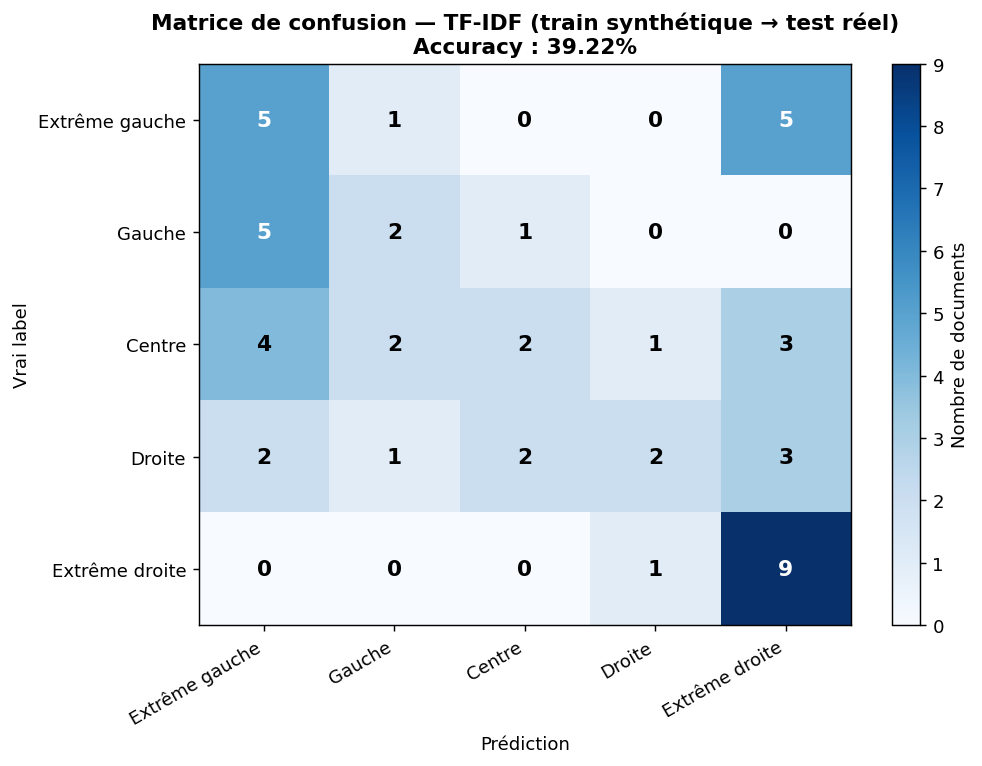

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=ORDER)
labels_list = [LABEL_NAMES[b] for b in ORDER]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(ORDER)))
ax.set_yticks(range(len(ORDER)))
ax.set_xticklabels(labels_list, rotation=30, ha='right')
ax.set_yticklabels(labels_list)

for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color=color, fontweight='bold', fontsize=12)

ax.set_xlabel('Prédiction')
ax.set_ylabel('Vrai label')
ax.set_title(
    f'Matrice de confusion — TF-IDF (train synthétique → test réel)\n'
    f'Accuracy : {acc:.2%}',
    fontweight='bold', fontsize=12
)
plt.colorbar(im, ax=ax, label='Nombre de documents')
plt.tight_layout()
plt.savefig('figures/tfidf_confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. Probabilités prédites par document (test réel)

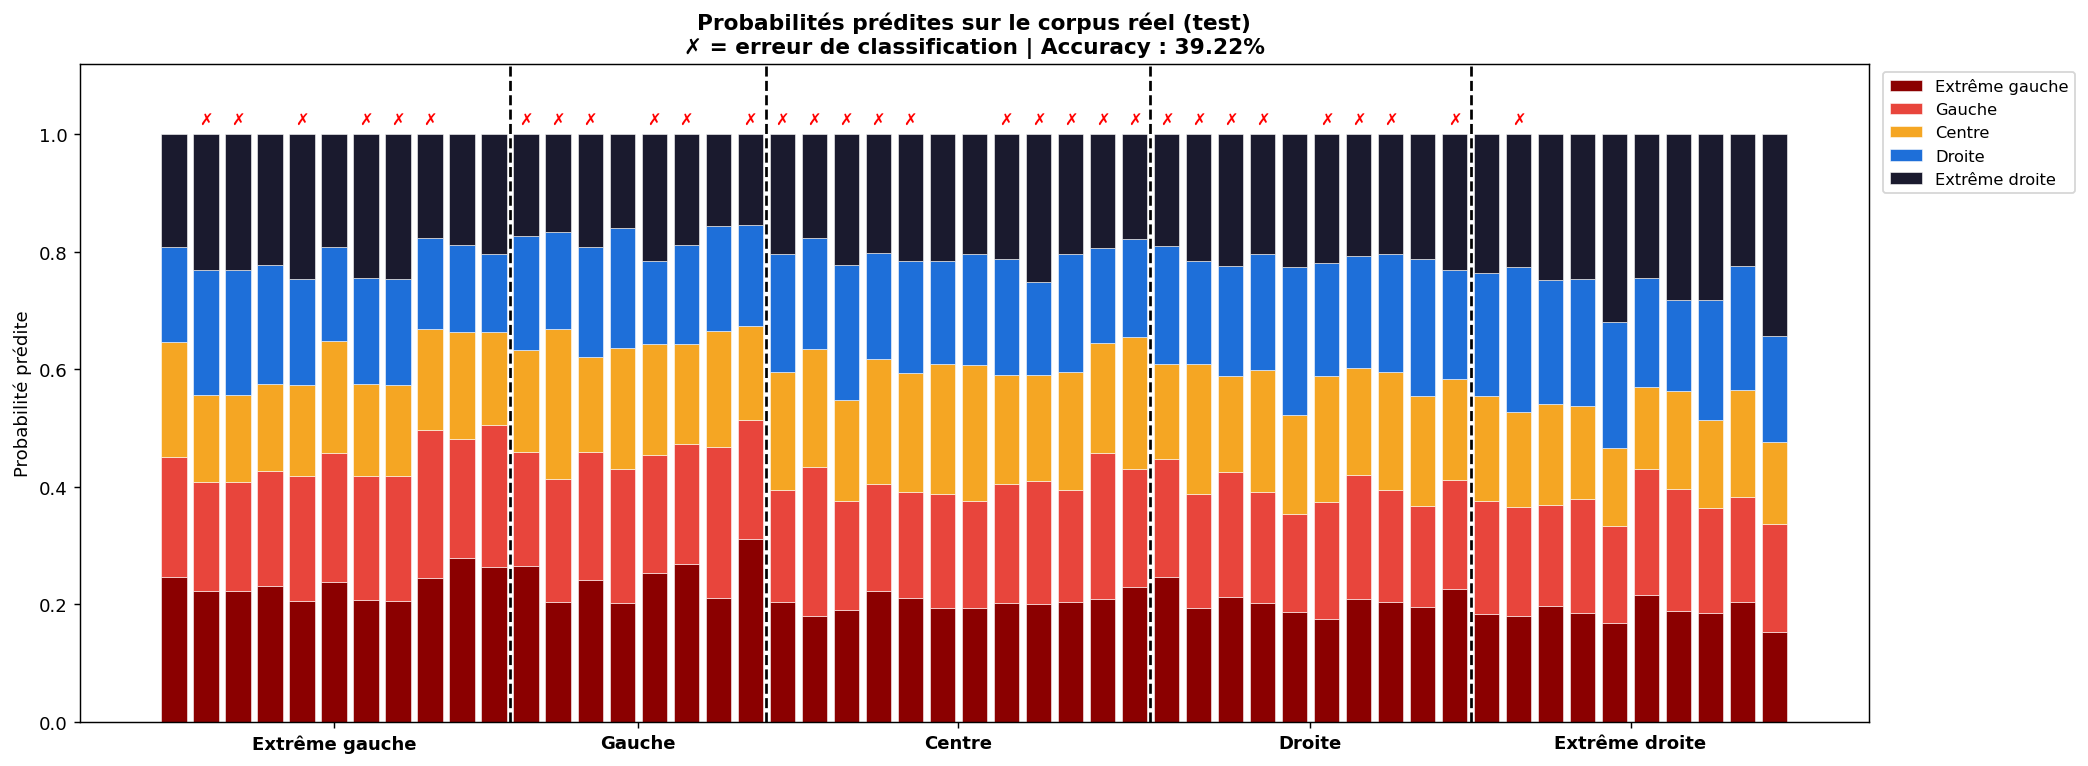

In [7]:
probas = clf.predict_proba(X_test)
classes_ordered = [c for c in ORDER if c in clf.classes_]
class_idx = [list(clf.classes_).index(c) for c in classes_ordered]

df_probas = pd.DataFrame(
    probas[:, class_idx],
    columns=[LABEL_NAMES[b] for b in classes_ordered]
)
df_probas['vrai_bord'] = [LABEL_NAMES[l] for l in y_test]
df_probas['correct']   = [p == t for p, t in zip(y_pred, y_test)]

bord_order_names = [LABEL_NAMES[b] for b in ORDER]
df_probas['vrai_bord_cat'] = pd.Categorical(
    df_probas['vrai_bord'], categories=bord_order_names, ordered=True
)
df_probas = df_probas.sort_values('vrai_bord_cat').reset_index(drop=True)
df_probas = df_probas.drop('vrai_bord_cat', axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
bottom = np.zeros(len(df_probas))

for bord in [LABEL_NAMES[b] for b in ORDER]:
    if bord not in df_probas.columns:
        continue
    color = COLORS[[k for k, v in LABEL_NAMES.items() if v == bord][0]]
    vals = df_probas[bord].values
    ax.bar(range(len(df_probas)), vals, bottom=bottom,
           label=bord, color=color, edgecolor='white', linewidth=0.3)
    bottom += vals

# Marqueurs d'erreur (X rouge)
for i, correct in enumerate(df_probas['correct']):
    if not correct:
        ax.text(i, 1.01, '✗', ha='center', va='bottom',
                color='red', fontsize=9, fontweight='bold')

# Séparateurs entre vrais bords
bord_col = df_probas['vrai_bord']
for i in range(1, len(bord_col)):
    if bord_col.iloc[i] != bord_col.iloc[i-1]:
        ax.axvline(x=i - 0.5, color='black', linewidth=1.5, linestyle='--')

# Labels des vrais bords
bord_positions, bord_names, start = [], [], 0
for i in range(1, len(bord_col)):
    if bord_col.iloc[i] != bord_col.iloc[i-1]:
        bord_positions.append((start + i - 1) / 2)
        bord_names.append(bord_col.iloc[start])
        start = i
bord_positions.append((start + len(bord_col) - 1) / 2)
bord_names.append(bord_col.iloc[start])

ax.set_xticks(bord_positions)
ax.set_xticklabels(bord_names, fontsize=10, fontweight='bold')
ax.set_ylabel('Probabilité prédite')
ax.set_ylim(0, 1.12)
ax.set_title(
    f'Probabilités prédites sur le corpus réel (test)\n'
    f'✗ = erreur de classification | Accuracy : {acc:.2%}',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='upper right', bbox_to_anchor=(1.12, 1), fontsize=9)
plt.tight_layout()
plt.savefig('figures/tfidf_probas_test.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Top termes discriminants par bord (coefficients du modèle)

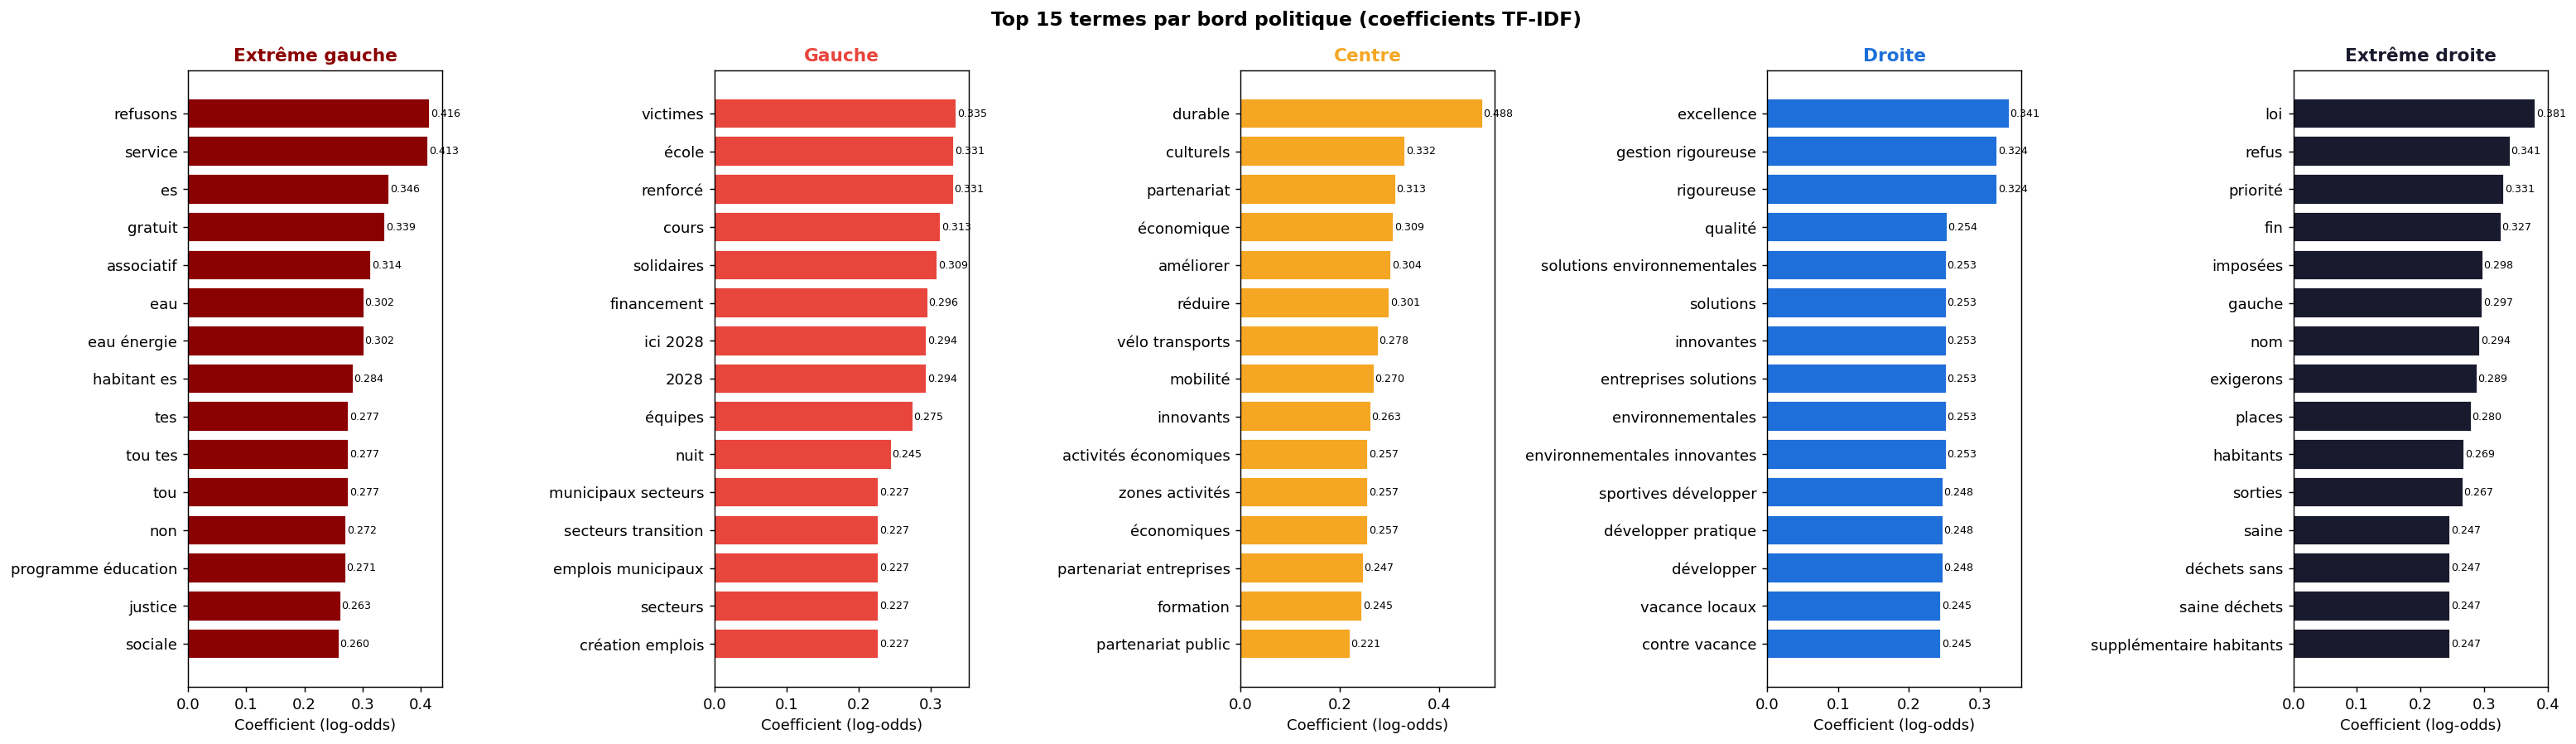

In [8]:
feature_names = vectorizer.get_feature_names_out()
fig, axes = plt.subplots(1, 5, figsize=(24, 7))

for ax, label in zip(axes, ORDER):
    if label not in clf.classes_:
        ax.axis('off')
        continue
    class_idx_model = list(clf.classes_).index(label)
    coefs = clf.coef_[class_idx_model]
    top_idx = np.argsort(coefs)[-15:][::-1]
    top_terms = feature_names[top_idx]
    top_vals  = coefs[top_idx]

    bars = ax.barh(list(reversed(top_terms)), list(reversed(top_vals)),
                   color=COLORS[label], edgecolor='white')
    for bar, val in zip(bars, list(reversed(top_vals))):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=7)

    ax.set_title(LABEL_NAMES[label], fontweight='bold', color=COLORS[label])
    ax.set_xlabel('Coefficient (log-odds)')

plt.suptitle('Top 15 termes par bord politique (coefficients TF-IDF)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/tfidf_coefs.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Résumé des performances

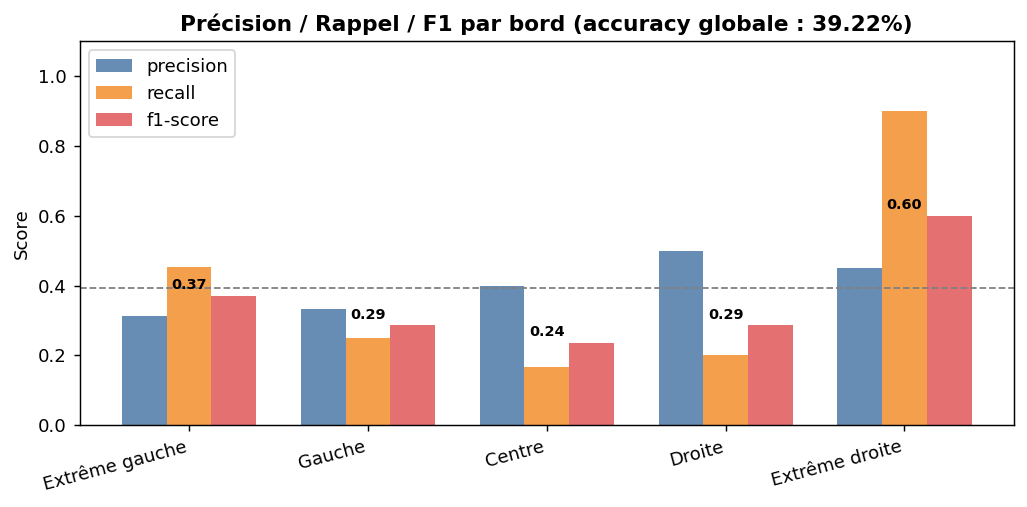


── Résumé ──────────────────────────────────────────────────
  Train : 200 docs synthétiques (40 / classe)
  Test  : 51 docs réels
  Accuracy test : 39.22%
────────────────────────────────────────────────────────────


In [9]:
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

report = classification_report(
    y_test, y_pred, labels=ORDER,
    target_names=[LABEL_NAMES[b] for b in ORDER],
    output_dict=True
)
df_report = pd.DataFrame(report).T
df_report = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
df_report = df_report.rename(index={LABEL_NAMES[b]: LABEL_NAMES[b] for b in ORDER})

fig, ax = plt.subplots(figsize=(8, 4))
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(df_report))
width = 0.25

bars_colors = ['#4e79a7', '#f28e2b', '#e15759']
for i, (metric, color) in enumerate(zip(metrics, bars_colors)):
    ax.bar(x + i * width, df_report[metric].astype(float),
           width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(df_report.index, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title(f'Précision / Rappel / F1 par bord (accuracy globale : {acc:.2%})',
             fontweight='bold')
ax.legend()
ax.axhline(y=acc, color='grey', linestyle='--', linewidth=1,
           label=f'Accuracy {acc:.2%}')

for i, row in enumerate(df_report.itertuples()):
    ax.text(i + width, float(row._3) + 0.02, f'{float(row._3):.2f}',
            ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/tfidf_metrics.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n── Résumé ──────────────────────────────────────────────────')
print(f'  Train : {len(X_train_raw)} docs synthétiques (40 / classe)')
print(f'  Test  : {len(X_test_raw)} docs réels')
print(f'  Accuracy test : {acc:.2%}')
print('────────────────────────────────────────────────────────────')